In [1]:
import os
import matplotlib.pyplot as plt

In [2]:
def read_result_file(file_path):
    with open(file_path, 'r') as f:
        results = f.readlines()

    result_dict = dict()
    k=0
    for l in results:
        l = l.strip()

        if l.strip() == 'S':
            embedding = 'S'
            result_dict[embedding] = dict()
        elif l.strip() == 'F':
            embedding = 'F'
            result_dict[embedding] = dict()
        elif l.strip() == 'FA':
            embedding = 'FA'
            result_dict[embedding] = dict()
        elif l.strip().startswith('k='):
            k = int(l[2:])
            result_dict[embedding][k] = {}
        elif l.strip().startswith('Best Epoch'):
            result_dict[embedding][k]['best_epoch'] = int(l.strip().split()[-1])
        elif l.strip().startswith('Baseline Accuracy'):
            result_dict[embedding][k]['baseline_acc'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Confidence AUC'):
            result_dict[embedding][k]['confidence_auc'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Confidence AUPR'):
            result_dict[embedding][k]['confidence_aupr'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Confidence FPR@95'):
            result_dict[embedding][k]['confidence_fpr@95'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Confidence Accuracy'):
            result_dict[embedding][k]['confidence_acc'] = float(l.strip().split()[-1])
            result_dict[embedding][k]['best_threshold'] = float(l.strip().split('=')[1].split(')')[0])
        elif l.strip().startswith('Test Accuracy'):
            result_dict[embedding][k]['accuracy'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test ROC-AUC'):
            result_dict[embedding][k]['auc'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test AUPR'):
            result_dict[embedding][k]['aupr'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test FPR@95'):
            result_dict[embedding][k]['fpr@95'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test Precision'):
            result_dict[embedding][k]['precision'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test recall'):
            result_dict[embedding][k]['recall'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test NPV'):
            result_dict[embedding][k]['npv'] = float(l.strip().split()[-1])
        elif l.strip().startswith('Test Specificity'):
            result_dict[embedding][k]['specificity'] = float(l.strip().split()[-1])

    return result_dict

In [3]:
"""
result_dict should be formatted:
{
    'label1': [1, 2, 3, 4, 5, 6, 7, 8],
    'label2': [2, 3, 4, 5, 6, 7, 8, 9],
    ...,
    'labeln': [n, ..., n]
}
If want to draw baseline line with the same color to other label, the label of baseline should be 'baseline_{the other label}'
"""

def draw_graph(result_dict, x, xlabel, ylabel, title, save_figure, save_dir=None):
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
    color_match_dict = {}
    color_idx = 0

    plt.figure(figsize=(10, 6))
    for label, values in result_dict.items():
        if 'baseline' in label:
            suffix = '_'.join(label.split('_')[1:])
            if suffix in color_match_dict:
                color = color_match_dict[suffix]
            else:
                color = colors[color_idx]
                color_idx += 1
                if suffix:
                    color_match_dict[suffix] = color
            plt.plot(x, values, linestyle='--', color=color, label=label)
        elif 'confidence' in label:
            suffix = '_'.join(label.split('_')[1:])
            if suffix in color_match_dict:
                color = color_match_dict[suffix]
            else:
                color = colors[color_idx]
                color_idx += 1
                if suffix:
                    color_match_dict[suffix] = color
            plt.plot(x, values, linestyle=':', color=color, label=label)
        else:
            if label in color_match_dict:
                color = color_match_dict[label]
            else:
                color = colors[color_idx]
                color_idx += 1
                color_match_dict[label] = color
            plt.plot(x, values, linestyle = '-', color = color, label=label)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    if save_figure:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, f'{title}.png'))
    plt.close()

### Codebert vs. FastText (not_add, label_criteria_1, nhot::normal)

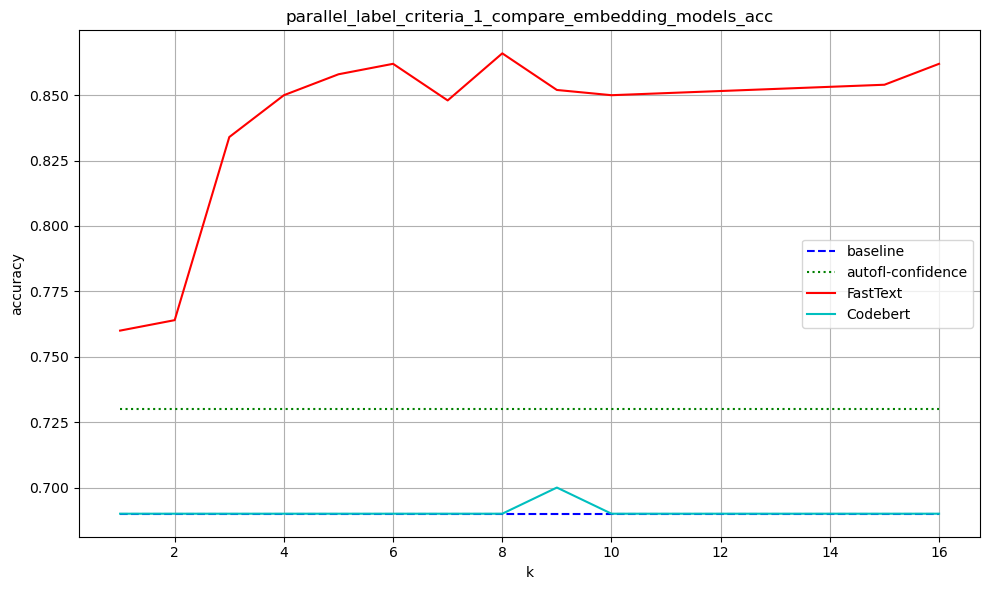

In [4]:
#Accuracy
result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)

ks = list(range(1, 11))
ks.extend([15, 16])
result_dict = {
    'baseline': [raw_result_dict['FA'][1]['baseline_acc']]*len(ks),
    'autofl-confidence': [raw_result_dict['FA'][1]['confidence_acc']]*len(ks),
    'FastText': [raw_result_dict['FA'][k]['accuracy'] for k in ks]
}

result_file = './parallel/embedding/codebert/nhot_normal/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Codebert'] = [raw_result_dict['FA'][k]['accuracy'] for k in ks]

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_label_criteria_1_compare_embedding_models_acc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)

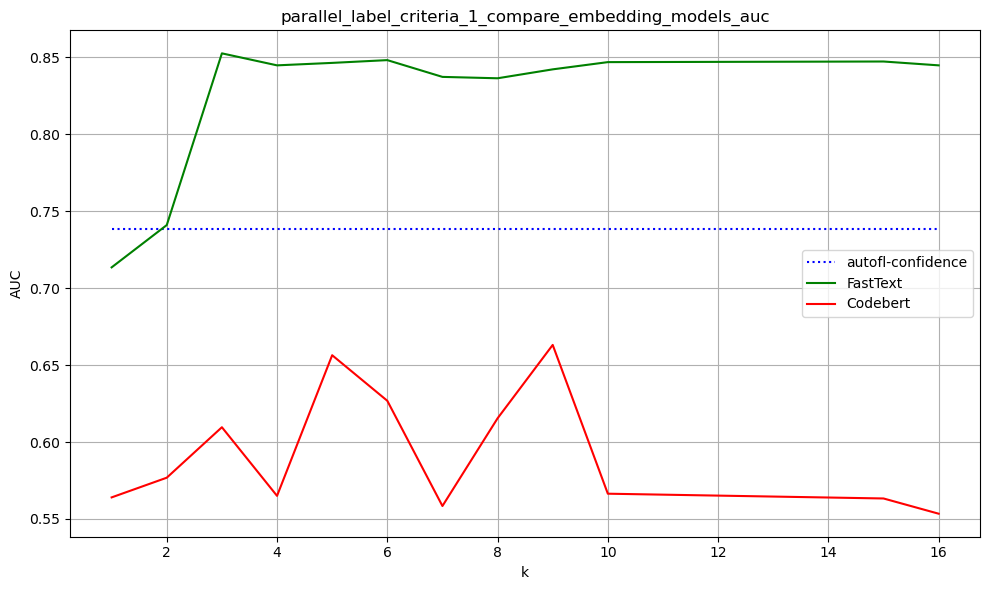

In [5]:
#AUC
result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)

ks = list(range(1, 11))
ks.extend([15, 16])
result_dict = {
    'autofl-confidence': [raw_result_dict['FA'][1]['confidence_auc']]*len(ks),
    'FastText': [raw_result_dict['FA'][k]['auc'] for k in ks]
}

result_file = './parallel/embedding/codebert/nhot_normal/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Codebert'] = [raw_result_dict['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_label_criteria_1_compare_embedding_models_auc'
save_dir = './graphs/parallel/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)

### Compare various embedding settings in FastText (Nhot::Normal, Label_criteria_1)

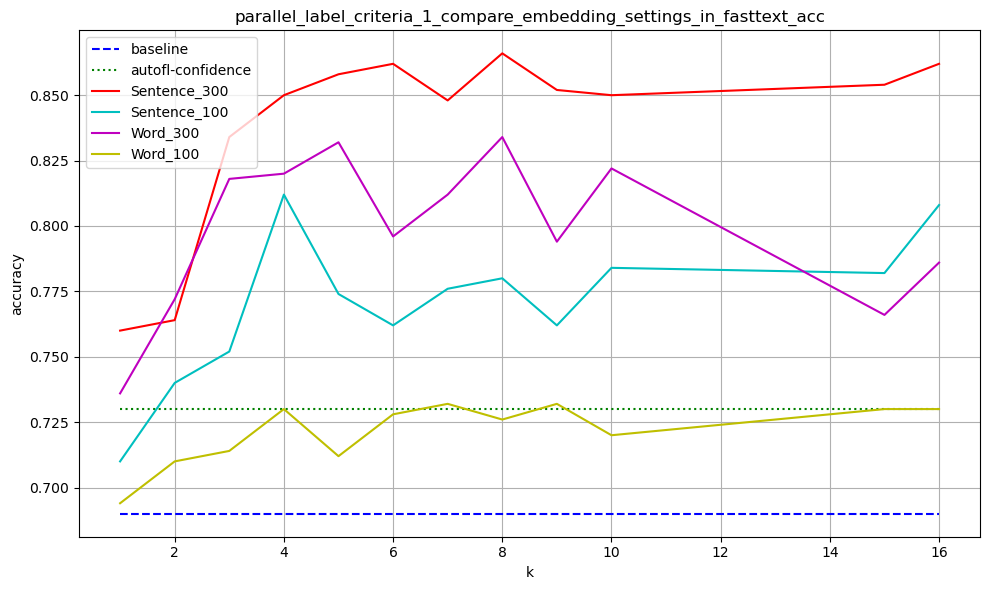

In [6]:
#Accuracy
result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)

ks = list(range(1, 11))
ks.extend([15, 16])
result_dict = {
    'baseline': [raw_result_dict['FA'][1]['baseline_acc']]*len(ks),
    'autofl-confidence': [raw_result_dict['FA'][1]['confidence_acc']]*len(ks),
    'Sentence_300': [raw_result_dict['FA'][k]['accuracy'] for k in ks]
}

result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/100d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Sentence_100'] = [raw_result_dict['FA'][k]['accuracy'] for k in ks]

result_file = './parallel/embedding/fasttext/nhot_normal/word_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Word_300'] = [raw_result_dict['FA'][k]['accuracy'] for k in ks]

result_file = './parallel/embedding/fasttext/nhot_normal/word_vector/100d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Word_100'] = [raw_result_dict['FA'][k]['accuracy'] for k in ks]

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_label_criteria_1_compare_embedding_settings_in_fasttext_acc'
save_dir = './graphs/parallel/fasttext/nhot_normal/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)

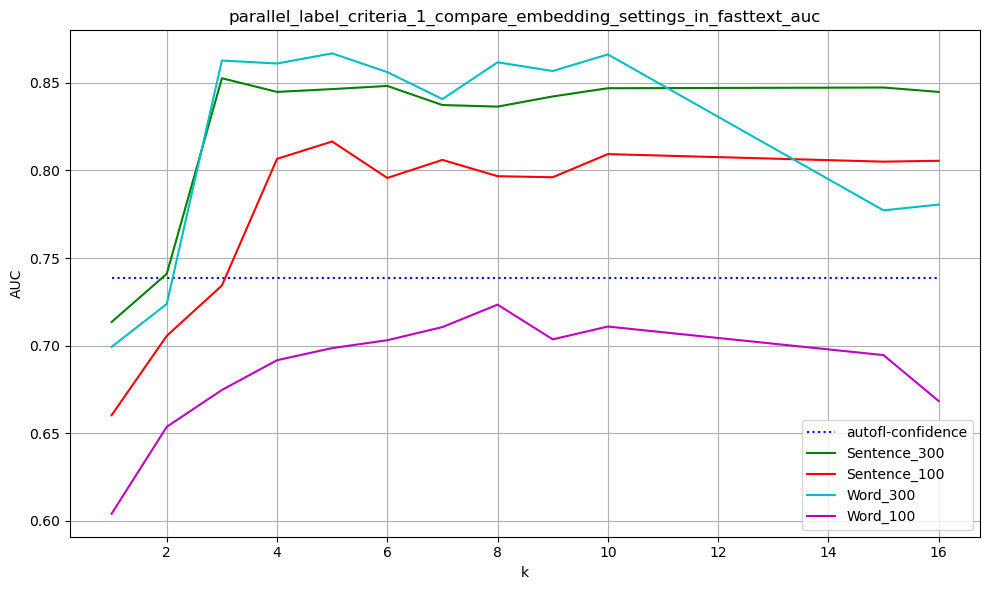

In [7]:
#AUC
result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)

ks = list(range(1, 11))
ks.extend([15, 16])
result_dict = {
    'autofl-confidence': [raw_result_dict['FA'][1]['confidence_auc']]*len(ks),
    'Sentence_300': [raw_result_dict['FA'][k]['auc'] for k in ks]
}

result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/100d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Sentence_100'] = [raw_result_dict['FA'][k]['auc'] for k in ks]

result_file = './parallel/embedding/fasttext/nhot_normal/word_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Word_300'] = [raw_result_dict['FA'][k]['auc'] for k in ks]

result_file = './parallel/embedding/fasttext/nhot_normal/word_vector/100d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Word_100'] = [raw_result_dict['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_label_criteria_1_compare_embedding_settings_in_fasttext_auc'
save_dir = './graphs/parallel/fasttext/nhot_normal/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)

### Compare Add vs. Not_add (FastText, Nhot::Normal, Label_criteria_1, Sentence_300)

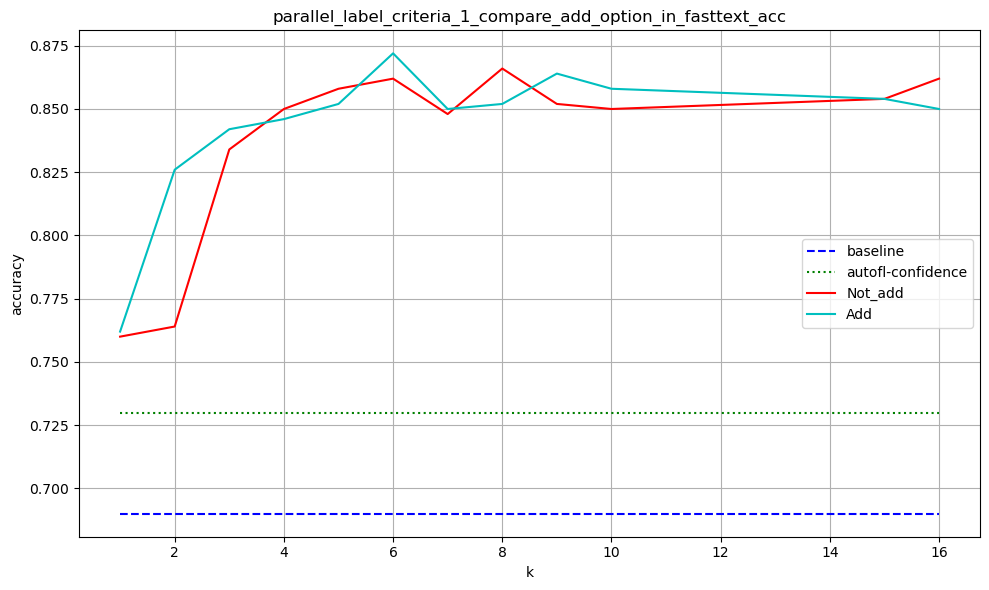

In [8]:
#Accuracy
result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)

ks = list(range(1, 11))
ks.extend([15, 16])
result_dict = {
    'baseline': [raw_result_dict['FA'][1]['baseline_acc']]*len(ks),
    'autofl-confidence': [raw_result_dict['FA'][1]['confidence_acc']]*len(ks),
    'Not_add': [raw_result_dict['FA'][k]['accuracy'] for k in ks]
}

result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/add/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Add'] = [raw_result_dict['FA'][k]['accuracy'] for k in ks]

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_label_criteria_1_compare_add_option_in_fasttext_acc'
save_dir = './graphs/parallel/fasttext/nhot_normal/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)

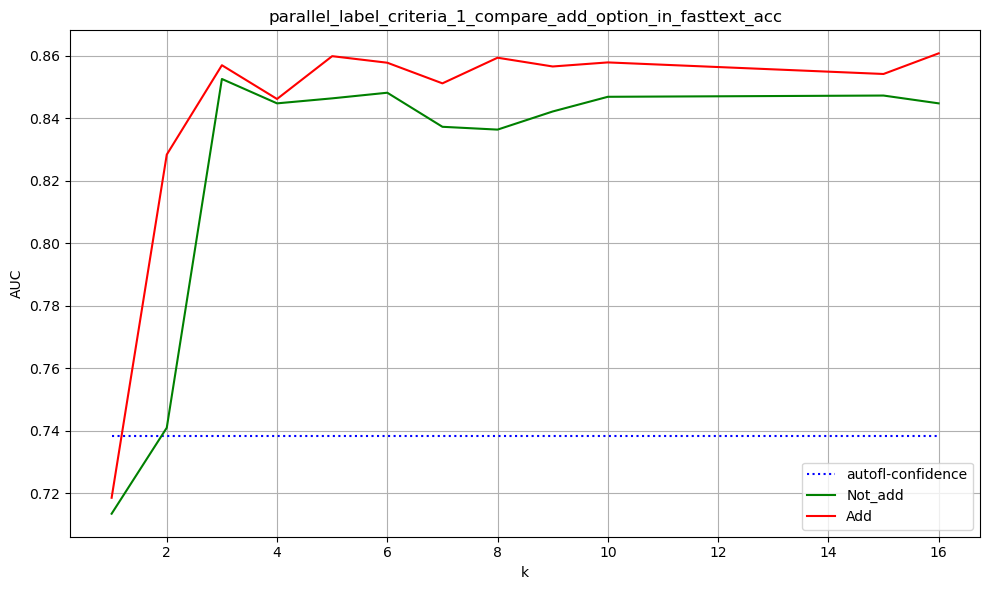

In [9]:
#AUC
result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)

ks = list(range(1, 11))
ks.extend([15, 16])
result_dict = {
    'autofl-confidence': [raw_result_dict['FA'][1]['confidence_auc']]*len(ks),
    'Not_add': [raw_result_dict['FA'][k]['auc'] for k in ks]
}

result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/add/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['Add'] = [raw_result_dict['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_label_criteria_1_compare_add_option_in_fasttext_acc'
save_dir = './graphs/parallel/fasttext/nhot_normal/label_criteria_1'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)

### Compare Label criteria (Nhot::Normal)

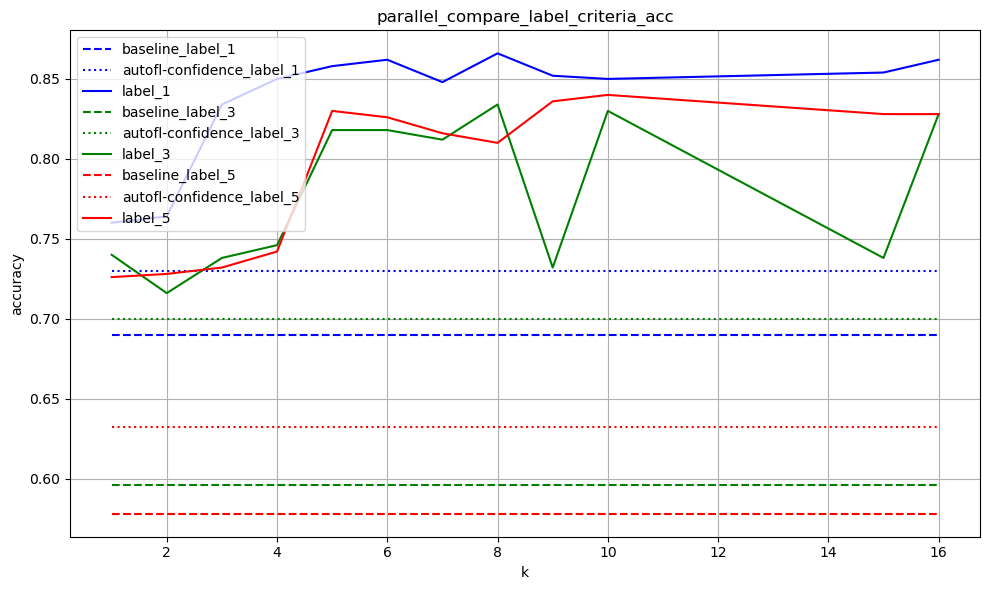

In [10]:
#Accuracy
result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)

ks = list(range(1, 11))
ks.extend([15, 16])
result_dict = {
    'baseline_label_1': [raw_result_dict['FA'][1]['baseline_acc']]*len(ks),
    'autofl-confidence_label_1': [raw_result_dict['FA'][1]['confidence_acc']]*len(ks),
    'label_1': [raw_result_dict['FA'][k]['accuracy'] for k in ks]
}

result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_3/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['baseline_label_3'] = [raw_result_dict['FA'][1]['baseline_acc']]*len(ks)
result_dict['autofl-confidence_label_3'] = [raw_result_dict['FA'][1]['confidence_acc']]*len(ks)
result_dict['label_3'] = [raw_result_dict['FA'][k]['accuracy'] for k in ks]

result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_5/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['baseline_label_5'] = [raw_result_dict['FA'][1]['baseline_acc']]*len(ks)
result_dict['autofl-confidence_label_5'] = [raw_result_dict['FA'][1]['confidence_acc']]*len(ks)
result_dict['label_5'] = [raw_result_dict['FA'][k]['accuracy'] for k in ks]

xlabel = 'k'
ylabel = 'accuracy'
title = 'parallel_compare_label_criteria_acc'
save_dir = './graphs/parallel/fasttext/nhot_normal'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)

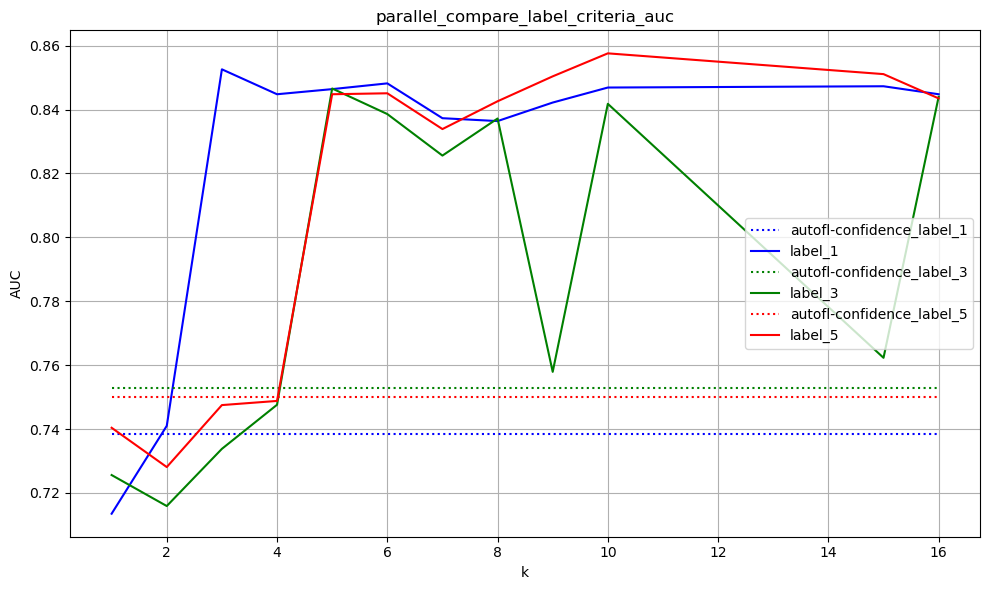

In [11]:
#AUC
result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_1/result.txt'
raw_result_dict = read_result_file(result_file)

ks = list(range(1, 11))
ks.extend([15, 16])
result_dict = {
    'autofl-confidence_label_1': [raw_result_dict['FA'][1]['confidence_auc']]*len(ks),
    'label_1': [raw_result_dict['FA'][k]['auc'] for k in ks]
}

result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_3/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['autofl-confidence_label_3'] = [raw_result_dict['FA'][1]['confidence_auc']]*len(ks)
result_dict['label_3'] = [raw_result_dict['FA'][k]['auc'] for k in ks]

result_file = './parallel/embedding/fasttext/nhot_normal/sentence_vector/300d/label_criteria_5/result.txt'
raw_result_dict = read_result_file(result_file)
result_dict['autofl-confidence_label_5'] = [raw_result_dict['FA'][1]['confidence_auc']]*len(ks)
result_dict['label_5'] = [raw_result_dict['FA'][k]['auc'] for k in ks]

xlabel = 'k'
ylabel = 'AUC'
title = 'parallel_compare_label_criteria_auc'
save_dir = './graphs/parallel/fasttext/nhot_normal'

draw_graph(result_dict, ks, xlabel, ylabel, title, save_figure=False, save_dir=save_dir)